# Variables Notebook
Compute terrain variables from 1m pre/post-fire DEMs using WhiteboxTools.

| Variable | File | Note |
|----------|------|------|
| Plan curvature pre   | `plan_curvature_pre_1m.tif`   | Pre-fire flow convergence/divergence |
| Plan curvature post  | `plan_curvature_post_1m.tif`  | Post-fire topographic reorganization |
| Plan curvature delta | `plan_curvature_delta_1m.tif` | post − pre: novel ML feature |

**Plan curvature** = curvature perpendicular to slope (contour shape).  
Negative = convergent hollow → flow concentrates → rill initiation zone.  
Positive = divergent nose/ridge → flow disperses.

All outputs → `/mnt/c/Users/amehedi/Downloads/thomas/variables/`

In [ ]:
from pathlib import Path
import numpy as np
import rasterio
import whitebox

wbt = whitebox.WhiteboxTools()
wbt.verbose = True
print('WhiteboxTools version:', wbt.version())

In [ ]:
# ── Paths ──────────────────────────────────────────────────────────
XDEM_DIR = Path('/mnt/c/Users/amehedi/Downloads/thomas/Thomas_xDEM')
PRE_DEM  = XDEM_DIR / 'final_pre_reference.tif'
POST_DEM = XDEM_DIR / 'final_post_corrected.tif'

OUT = Path('/mnt/c/Users/amehedi/Downloads/thomas/variables')
OUT.mkdir(exist_ok=True)

print('PRE  exists:', PRE_DEM.exists())
print('POST exists:', POST_DEM.exists())
print('Output dir :', OUT)

In [ ]:
# ── Helpers ────────────────────────────────────────────────────────
def read_raster(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype('float64')
        profile = src.profile
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
    return arr, profile

def write_raster(path, arr, profile):
    p = profile.copy()
    p.update(dtype='float32', nodata=-9999.0, compress='lzw', count=1)
    out = np.where(np.isfinite(arr), arr, -9999.0).astype('float32')
    with rasterio.open(path, 'w', **p) as dst:
        dst.write(out, 1)
    print(f'  wrote {Path(path).name}  shape={out.shape}')

## Plan Curvature — Pre, Post, Delta
No sink filling needed — curvature is a pure DEM surface derivative, not flow-routed.

In [ ]:
# ── Plan curvature pre ─────────────────────────────────────────────
plan_pre_path = OUT / 'plan_curvature_pre_1m.tif'

print('Computing plan curvature pre ...')
wbt.plan_curvature(str(PRE_DEM), str(plan_pre_path))
print('Done.')

In [ ]:
# ── Plan curvature post ────────────────────────────────────────────
plan_post_path = OUT / 'plan_curvature_post_1m.tif'

print('Computing plan curvature post ...')
wbt.plan_curvature(str(POST_DEM), str(plan_post_path))
print('Done.')

In [ ]:
# ── Delta = post - pre ─────────────────────────────────────────────
plan_delta_path = OUT / 'plan_curvature_delta_1m.tif'

pre,  profile = read_raster(plan_pre_path)
post, _       = read_raster(plan_post_path)

delta = post - pre
write_raster(plan_delta_path, delta, profile)

print(f'\nDelta stats:')
print(f'  min  = {np.nanmin(delta):.4f}')
print(f'  max  = {np.nanmax(delta):.4f}')
print(f'  mean = {np.nanmean(delta):.4f}')
print(f'  std  = {np.nanstd(delta):.4f}')

In [ ]:
# ── Sanity check — histogram ───────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Plan curvature at 1m', fontsize=13)

for ax, (label, path) in zip(axes, [
    ('pre',   plan_pre_path),
    ('post',  plan_post_path),
    ('delta', plan_delta_path),
]):
    arr, _ = read_raster(path)
    vals = arr[np.isfinite(arr)]
    p1, p99 = np.percentile(vals, [1, 99])
    ax.hist(vals[(vals >= p1) & (vals <= p99)], bins=100, color='steelblue', alpha=0.8)
    ax.axvline(0, color='red', linestyle='--', linewidth=1, label='0')
    ax.set_title(f'Plan curvature — {label}')
    ax.set_xlabel('value')
    ax.set_ylabel('count')
    ax.legend()

plt.tight_layout()
plt.show()

## G CDF — Hillslope Domain [0, 300] with Fitted Gamma

Shows the empirical CDF of G_mean values in the hillslope domain [g_min, g_channel)  
overlaid with the fitted Gamma(k, scale) CDF from `ceff_fit.json`.

Gamma fit:  k=2.1291  scale=13.6977  mean G=29.16
Hillslope cells used for fit: 210,577
Hillslope G values: n=354,300  min=5.00  max=299.99


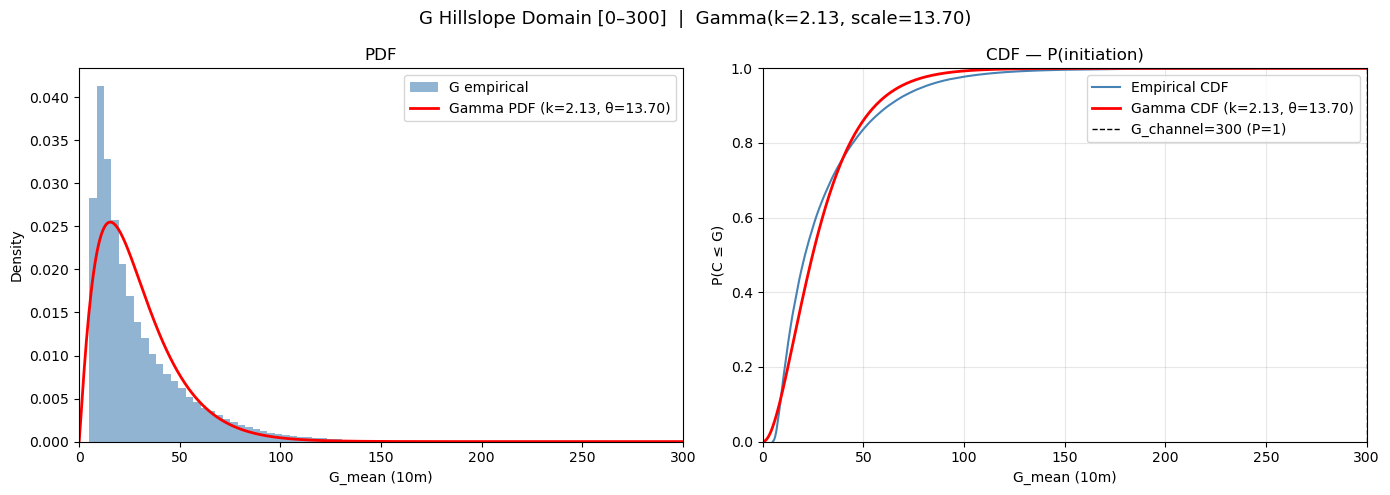

Saved: G_cdf_gamma_fit.png


In [13]:
import json
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from pathlib import Path
from scipy.stats import gamma

# ── Paths ──────────────────────────────────────────────────────────
LABELS_DIR   = Path('/mnt/c/Users/amehedi/Downloads/source_zone_labels')
G_MEAN_PATH  = LABELS_DIR / 'G_mean_10m.tif'
MASK_PATH    = LABELS_DIR / 'channel_mask_10m.tif'
CEFF_FIT     = LABELS_DIR / 'ceff_fit.json'

# ── Load Gamma fit params ──────────────────────────────────────────
with open(CEFF_FIT) as f:
    fit = json.load(f)

k     = fit['k']
scale = fit['scale']
print(f'Gamma fit:  k={k:.4f}  scale={scale:.4f}  mean G={fit["mean_g"]:.2f}')
print(f'Hillslope cells used for fit: {fit["n_hillslope"]:,}')

# ── Load G_mean and channel mask ───────────────────────────────────
def load(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype('float64')
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
    return arr

g_mean = load(G_MEAN_PATH)
ch_mask = load(MASK_PATH) > 0.5

# ── Hillslope G values ─────────────────────────────────────────────
g_vals = g_mean[ch_mask & np.isfinite(g_mean)]
g_vals = g_vals[(g_vals >= 0) & (g_vals < 300)]
print(f'Hillslope G values: n={len(g_vals):,}  min={g_vals.min():.2f}  max={g_vals.max():.2f}')

# ── Plot ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'G Hillslope Domain [0–300]  |  Gamma(k={k:.2f}, scale={scale:.2f})', fontsize=13)

g_range = np.linspace(0, 300, 500)
gamma_cdf = gamma.cdf(g_range, a=k, scale=scale)
gamma_pdf = gamma.pdf(g_range, a=k, scale=scale)

# Left: PDF / histogram
axes[0].hist(g_vals, bins=80, density=True, color='steelblue', alpha=0.6, label='G empirical')
axes[0].plot(g_range, gamma_pdf, 'r-', linewidth=2, label=f'Gamma PDF (k={k:.2f}, θ={scale:.2f})')
axes[0].set_xlabel('G_mean (10m)')
axes[0].set_ylabel('Density')
axes[0].set_title('PDF')
axes[0].legend()
axes[0].set_xlim(0, 300)

# Right: CDF
g_sorted = np.sort(g_vals)
ecdf = np.arange(1, len(g_sorted) + 1) / len(g_sorted)
axes[1].plot(g_sorted, ecdf, color='steelblue', linewidth=1.5, label='Empirical CDF')
axes[1].plot(g_range, gamma_cdf, 'r-', linewidth=2, label=f'Gamma CDF (k={k:.2f}, θ={scale:.2f})')
axes[1].axvline(300, color='black', linestyle='--', linewidth=1, label='G_channel=300 (P=1)')
axes[1].set_xlabel('G_mean (10m)')
axes[1].set_ylabel('P(C ≤ G)')
axes[1].set_title('CDF — P(initiation)')
axes[1].legend()
axes[1].set_xlim(0, 300)
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(LABELS_DIR / 'G_cdf_gamma_fit.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: G_cdf_gamma_fit.png')

## Next: align to 10m reference grid

Add to `scripts/10_align_features.py` → `TO_ALIGN` list:

```python
VAR_DIR = Path('/mnt/c/Users/amehedi/Downloads/thomas/variables')

(VAR_DIR / 'plan_curvature_pre_1m.tif',   'plan_curv_pre_aligned.tif',   Resampling.bilinear),
(VAR_DIR / 'plan_curvature_post_1m.tif',  'plan_curv_post_aligned.tif',  Resampling.bilinear),
(VAR_DIR / 'plan_curvature_delta_1m.tif', 'plan_curv_delta_aligned.tif', Resampling.bilinear),
```

Then add to `config/ml_random_forest_tune.yaml`:
```yaml
feature_paths:
  plan_curv_pre:   /mnt/c/Users/amehedi/Downloads/thomas/aligned/plan_curv_pre_aligned.tif
  plan_curv_post:  /mnt/c/Users/amehedi/Downloads/thomas/aligned/plan_curv_post_aligned.tif
  plan_curv_delta: /mnt/c/Users/amehedi/Downloads/thomas/aligned/plan_curv_delta_aligned.tif

features:
  numeric:
    - plan_curv_pre
    - plan_curv_post
    - plan_curv_delta
```

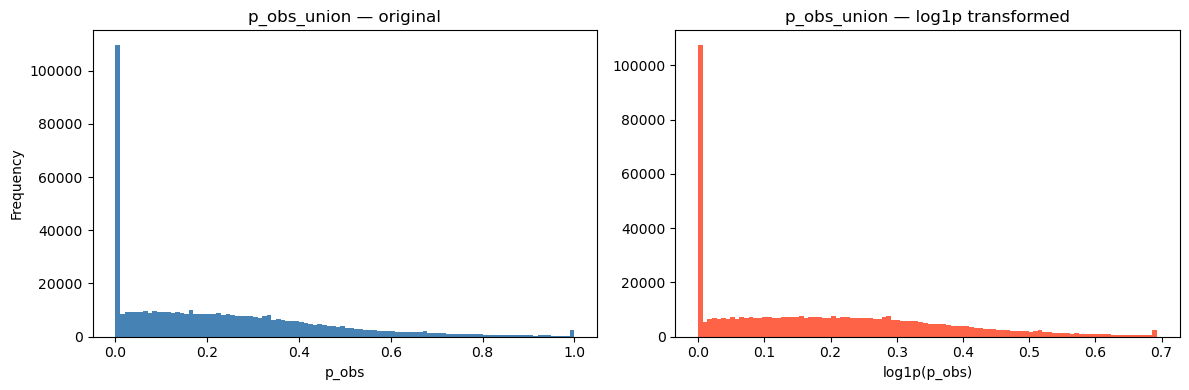

Original  — mean=0.2324  std=0.2207  min=0.0000  max=1.0000
log1p     — mean=0.1942  std=0.1688  min=0.0000  max=0.6931


In [2]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt

with rasterio.open(r"/mnt/c/Users/amehedi/Downloads/thomas/aligned/p_obs_union_aligned.tif") as src:
    arr = src.read(1).astype("float32")
    nd = src.nodata
    data = arr[arr != nd]
    data = data[np.isfinite(data)]

log_data = np.log1p(data)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(data, bins=100, color="steelblue", edgecolor="none")
axes[0].set_title("p_obs_union — original")
axes[0].set_xlabel("p_obs"); axes[0].set_ylabel("Frequency")

axes[1].hist(log_data, bins=100, color="tomato", edgecolor="none")
axes[1].set_title("p_obs_union — log1p transformed")
axes[1].set_xlabel("log1p(p_obs)")

plt.tight_layout()
plt.show()

print(f"Original  — mean={data.mean():.4f}  std={data.std():.4f}  min={data.min():.4f}  max={data.max():.4f}")
print(f"log1p     — mean={log_data.mean():.4f}  std={log_data.std():.4f}  min={log_data.min():.4f}  max={log_data.max():.4f}")


d50     = 1.0 mm
tau_c   = 0.7608 Pa   (Shields: tau_* × (rho_s-rho_w) × g × d50)
n_b     = 0.01499 s/m^(1/3)   (Strickler: d50^(1/6) / 21.1)
n_a     = 0.000 s/m^(1/3)   (post-fire bare soil)
n_total = 0.01499 s/m^(1/3)

Mean precip Jan 9  : 45.6 mm  (range 29.1–60.6 mm)
Mean storm intensity: 7.60 mm/hr
Mean runoff rate r  : 5.96 mm/hr  = 1.66 ×10⁻⁶ m/s

C_phys [m]:
  min=3.95  p25=4.44  median=5.65  mean=6.24  p75=8.04  max=14.42
  valid pixels: 519,191
  Saved → /mnt/c/Users/amehedi/Downloads/thomas/aligned/C_physics_aligned.tif
  Saved → /mnt/c/Users/amehedi/Downloads/thomas/aligned/C_physics_log_aligned.tif

d50 sensitivity (tau_star=0.047, mean r=5.96 mm/hr):
       d50     tau_c       n_b    C_median
     0.5 mm    0.3804 Pa   0.01335        2.01 m
     1.0 mm    0.7608 Pa   0.01499        5.68 m
     2.0 mm    1.5215 Pa   0.01682       16.07 m
     5.0 mm    3.8038 Pa   0.01960       63.53 m
    10.0 mm    7.6077 Pa   0.02200      179.69 m
    20.0 mm   15.2153 Pa   0.02469     

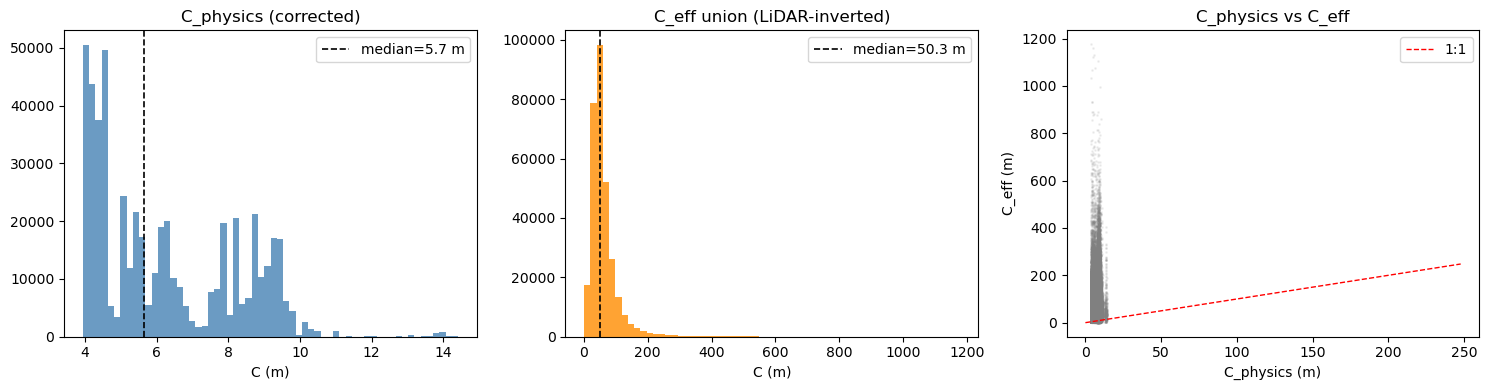

In [1]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# ════════════════════════════════════════════════════════════════════
# C — Channel Initiation Threshold  (Istanbulluoglu & Bras 2005, eq. 11)
#
#   C = ( tau_c / (rho_w · g · n_b^1.5 · (n_b + n_a)^-0.9 · r^m1) )^(1/m1)
#
# Units check:
#   tau_c               [Pa = kg / (m·s²)]
#   rho_w · g           [kg/m³ · m/s² = kg/(m²·s²)]
#   n_b, n_a            [s / m^(1/3)]  — Manning roughness
#   r                   [m/s]          — mean runoff rate
#   → RHS gives [m^0.6]^(1/0.6) = [m]
#   → C in [m], same units as G = a·S  ✓
# ════════════════════════════════════════════════════════════════════

BASE    = "/mnt/c/Users/amehedi/Downloads/thomas/aligned/"
OUT_DIR = BASE

# ── Fixed physics constants ─────────────────────────────────────────
rho_w = 1000.0   # kg/m³
rho_s = 2650.0   # kg/m³
g     = 9.81     # m/s²
m1    = 0.6      # Manning overland flow exponent (Willgoose et al. 1991)

# ── Grain size — single representative value for AOI ───────────────
# Soil texture: sand=56%, silt=26%, clay=19% → sandy loam.
# n_b and tau_c both derived from d50 for internal consistency.
# Surface lag on post-fire chaparral may be coarser than bulk soil;
# sweep below covers the plausible range.
d50_m    = 0.001          # m  (1 mm — central estimate; sweep: 0.5–10 mm)
tau_star = 0.047          # Shields dimensionless critical shear stress

tau_c = tau_star * (rho_s - rho_w) * g * d50_m   # Pa
n_b   = d50_m**(1.0/6.0) / 21.1                   # s/m^(1/3)  — Strickler

# ── Post-fire vegetation roughness ─────────────────────────────────
# Thomas Fire high severity → essentially bare hillslopes
n_a = 0.0   # s/m^(1/3)

print(f"d50     = {d50_m*1000:.1f} mm")
print(f"tau_c   = {tau_c:.4f} Pa   (Shields: tau_* × (rho_s-rho_w) × g × d50)")
print(f"n_b     = {n_b:.5f} s/m^(1/3)   (Strickler: d50^(1/6) / 21.1)")
print(f"n_a     = {n_a:.3f} s/m^(1/3)   (post-fire bare soil)")
print(f"n_total = {n_b + n_a:.5f} s/m^(1/3)")

# ── Storm parameters — Jan 9 2018 ──────────────────────────────────
# Use MEAN storm runoff rate, NOT peak I15.
# Peak I15 (90 mm/hr) overestimates r by ~12× → underestimates C by ~12×.
# Critical period: ~04:00–10:00 PST → 6 hr duration.
STORM_DURATION_HR = 6.0   # hours

# Post-fire runoff coefficient Cr by NLCD class
# (captures spatial variability in hydrophobicity and land cover)
NLCD_CR = {
    21: 0.60,   # Developed Open Space
    22: 0.70,   # Developed Low Intensity
    23: 0.80,   # Developed Medium Intensity
    24: 0.85,   # Developed High Intensity
    42: 0.80,   # Evergreen Forest (post-fire, high severity)
    43: 0.80,   # Mixed Forest (post-fire)
    52: 0.85,   # Shrub/Scrub — chaparral, highest hydrophobicity post-fire
    71: 0.70,   # Grassland/Herbaceous
    90: 0.40,   # Woody Wetlands
}
DEFAULT_CR = 0.80

# ── Load rasters ────────────────────────────────────────────────────
with rasterio.open(BASE + "landcover_aligned.tif") as src:
    lc    = src.read(1).astype(float)
    prof  = src.profile
    nd_lc = src.nodata

with rasterio.open(BASE + "precip_jan9_aligned.tif") as src:
    precip_mm = src.read(1).astype(float)
    nd_p      = src.nodata

# mask nodata
if nd_lc is not None: lc[np.isclose(lc, nd_lc)] = np.nan
if nd_p  is not None: precip_mm[np.isclose(precip_mm, nd_p)] = np.nan

# ── Spatially variable Cr map ───────────────────────────────────────
Cr_map = np.full_like(lc, DEFAULT_CR)
for cls, cr in NLCD_CR.items():
    Cr_map[lc == cls] = cr

# ── Mean runoff rate r (m/s) ────────────────────────────────────────
# r = Cr × (total precip / storm duration)
# precip_mm [mm] / (duration [hr] × 3600 [s/hr] × 1000 [mm/m]) → [m/s]
mean_i_ms = precip_mm / (STORM_DURATION_HR * 3600.0 * 1000.0)  # m/s
r_map     = Cr_map * mean_i_ms                                  # m/s

print(f"\nMean precip Jan 9  : {np.nanmean(precip_mm):.1f} mm  "
      f"(range {np.nanmin(precip_mm):.1f}–{np.nanmax(precip_mm):.1f} mm)")
print(f"Mean storm intensity: {np.nanmean(mean_i_ms)*3600*1000:.2f} mm/hr")
print(f"Mean runoff rate r  : {np.nanmean(r_map)*3600*1000:.2f} mm/hr  "
      f"= {np.nanmean(r_map)*1e6:.2f} ×10⁻⁶ m/s")

# ── Compute C (m) ───────────────────────────────────────────────────
n_total = n_b + n_a
with np.errstate(invalid="ignore", divide="ignore"):
    denom  = (rho_w * g * (n_b**1.5) * (n_total**(-0.9))
              * np.where(r_map > 0, r_map**m1, np.nan))
    C_phys = (tau_c / denom) ** (1.0 / m1)

# mask invalid
invalid = (~np.isfinite(r_map)) | (r_map <= 0) | (~np.isfinite(C_phys)) | (~np.isfinite(lc))
C_phys[invalid] = np.nan

print(f"\nC_phys [m]:")
print(f"  min={np.nanmin(C_phys):.2f}  p25={np.nanpercentile(C_phys,25):.2f}  "
      f"median={np.nanmedian(C_phys):.2f}  mean={np.nanmean(C_phys):.2f}  "
      f"p75={np.nanpercentile(C_phys,75):.2f}  max={np.nanmax(C_phys):.2f}")
print(f"  valid pixels: {np.isfinite(C_phys).sum():,}")

# ── Write outputs ───────────────────────────────────────────────────
def write_tif(path, arr, profile):
    out = np.where(np.isfinite(arr), arr, -9999.0).astype("float32")
    p = profile.copy()
    p.update(dtype="float32", count=1, nodata=-9999.0, compress="lzw")
    with rasterio.open(path, "w", **p) as dst:
        dst.write(out, 1)
    print(f"  Saved → {path}")

write_tif(OUT_DIR + "C_physics_aligned.tif",     C_phys,              prof)
write_tif(OUT_DIR + "C_physics_log_aligned.tif", np.log(np.clip(C_phys, 1e-6, None)), prof)

# ── d50 sensitivity sweep ───────────────────────────────────────────
r_mean = np.nanmean(r_map)
print(f"\nd50 sensitivity (tau_star=0.047, mean r={r_mean*3600*1000:.2f} mm/hr):")
print(f"  {'d50':>8}  {'tau_c':>8}  {'n_b':>8}  {'C_median':>10}")
for d50_mm in [0.5, 1.0, 2.0, 5.0, 10.0, 20.0]:
    d   = d50_mm / 1000.0
    tc  = tau_star * (rho_s - rho_w) * g * d
    nb  = d**(1.0/6.0) / 21.1
    nt  = nb + n_a
    c   = (tc / (rho_w * g * nb**1.5 * nt**(-0.9) * r_mean**m1))**(1.0/m1)
    print(f"  {d50_mm:>6.1f} mm  {tc:>8.4f} Pa  {nb:>8.5f}  {c:>10.2f} m")

# ── Compare against LiDAR-inverted C_eff ───────────────────────────
print("\n── Comparison: C_physics vs LiDAR-inverted C_eff ──")
for label, ceff_path in [
    ("C_eff union", OUT_DIR + "C_p_obs_union_aligned.tif"),
    ("C_eff inter", OUT_DIR + "C_p_obs_inter_aligned.tif"),
]:
    try:
        with rasterio.open(ceff_path) as src:
            C_inv = src.read(1).astype(float)
            if src.nodata is not None:
                C_inv[np.isclose(C_inv, src.nodata)] = np.nan
        both = np.isfinite(C_phys) & np.isfinite(C_inv)
        rho, _ = spearmanr(C_phys[both], C_inv[both])
        print(f"  {label}:  n={both.sum():,}  "
              f"C_phys median={np.nanmedian(C_phys[both]):.2f}  "
              f"C_eff median={np.nanmedian(C_inv[both]):.2f}  "
              f"ratio={np.nanmedian(C_inv[both])/np.nanmedian(C_phys[both]):.1f}×  "
              f"Spearman ρ={rho:.3f}")
    except Exception as e:
        print(f"  {label}: skipped — {e}")

# ── Plot: distributions + spatial comparison ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(C_phys[np.isfinite(C_phys)], bins=60, color="steelblue", alpha=0.8)
axes[0].axvline(np.nanmedian(C_phys), color="black", ls="--", lw=1.2,
                label=f"median={np.nanmedian(C_phys):.1f} m")
axes[0].set_title("C_physics (corrected)"); axes[0].set_xlabel("C (m)"); axes[0].legend()

try:
    with rasterio.open(OUT_DIR + "C_p_obs_union_aligned.tif") as src:
        C_inv = src.read(1).astype(float)
        if src.nodata: C_inv[np.isclose(C_inv, src.nodata)] = np.nan
    axes[1].hist(C_inv[np.isfinite(C_inv)], bins=60, color="darkorange", alpha=0.8)
    axes[1].axvline(np.nanmedian(C_inv), color="black", ls="--", lw=1.2,
                    label=f"median={np.nanmedian(C_inv):.1f} m")
    axes[1].set_title("C_eff union (LiDAR-inverted)"); axes[1].set_xlabel("C (m)"); axes[1].legend()

    both = np.isfinite(C_phys) & np.isfinite(C_inv)
    axes[2].scatter(C_phys[both], C_inv[both], s=1, alpha=0.1, color="grey")
    lim = max(np.nanpercentile(C_phys[both], 99), np.nanpercentile(C_inv[both], 99))
    axes[2].plot([0, lim], [0, lim], "r--", lw=1, label="1:1")
    axes[2].set_xlabel("C_physics (m)"); axes[2].set_ylabel("C_eff (m)")
    axes[2].set_title("C_physics vs C_eff"); axes[2].legend()
except Exception:
    pass

plt.tight_layout()
plt.show()


                     n       min       p25    median      mean       p75       max
C_physics      519,191      3.00      3.34      4.32      5.39      8.00     11.73
C_union        308,432      0.63     36.50     50.26     61.37     71.72   1176.07
C_inter        132,484      0.65     91.62    144.23    185.20    231.28   2045.30


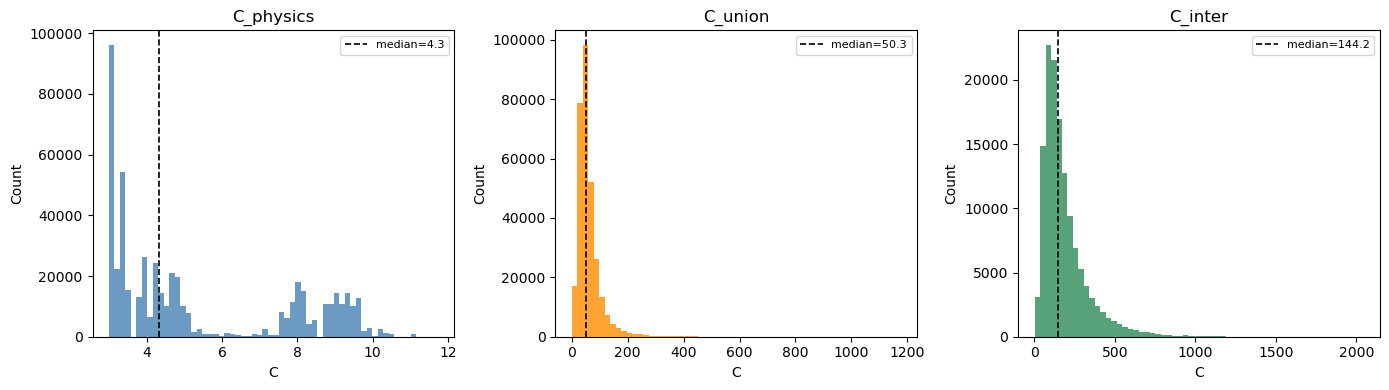

In [6]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt

BASE = "/mnt/c/Users/amehedi/Downloads/thomas/aligned/"

files = {
    "C_physics": BASE + "C_physics_aligned.tif",
    "C_union"  : BASE + "C_p_obs_union_aligned.tif",
    "C_inter"  : BASE + "C_p_obs_inter_aligned.tif",
}

arrays = {}
for name, path in files.items():
    with rasterio.open(path) as src:
        arr = src.read(1).astype(float)
        nd  = src.nodata
    if nd is not None:
        arr[np.isclose(arr, nd)] = np.nan
    arrays[name] = arr[np.isfinite(arr)]

# ── Descriptive stats ────────────────────────────────────────────────────────
print(f"{'':12s}  {'n':>8}  {'min':>8}  {'p25':>8}  {'median':>8}  {'mean':>8}  {'p75':>8}  {'max':>8}")
for name, v in arrays.items():
    print(f"{name:12s}  {len(v):>8,}  {np.nanmin(v):>8.2f}  "
          f"{np.percentile(v,25):>8.2f}  {np.median(v):>8.2f}  "
          f"{np.mean(v):>8.2f}  {np.percentile(v,75):>8.2f}  {np.nanmax(v):>8.2f}")

# ── Histograms ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
colors = ["steelblue", "darkorange", "seagreen"]

for ax, (name, v), color in zip(axes, arrays.items(), colors):
    ax.hist(v, bins=60, color=color, alpha=0.8, edgecolor="none")
    ax.axvline(np.median(v), color="black", lw=1.2, ls="--", label=f"median={np.median(v):.1f}")
    ax.set_title(name)
    ax.set_xlabel("C")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


G_mean_10m — Dunne polygons
  partB         n= 4,269  min=    5.03  p25=   11.84  med=   20.37  mean=   27.38  p75=   36.38  max=  192.81
  partC         n= 9,965  min=    5.08  p25=   14.48  med=   24.83  mean=   32.76  p75=   43.58  max=  189.67
  partD         n=12,974  min=    5.05  p25=   13.29  med=   23.18  mean=   31.01  p75=   41.10  max=  241.62

G_mean_10m — Erosion label classes
  class 0       n= 1,002  min=    5.03  p25=    7.36  med=    9.06  mean=   12.53  p75=   14.01  max=   84.02
  class 1       n= 1,988  min=    5.76  p25=   15.29  med=   24.43  mean=   30.42  p75=   40.26  max=  127.65
  class 2       n= 2,383  min=    5.48  p25=   17.43  med=   29.41  mean=   36.39  p75=   49.39  max=  164.96
  class 3       n=   453  min=    7.03  p25=   22.28  med=   34.96  mean=   41.41  p75=   54.48  max=  142.01
  class 4       n=   316  min=    5.07  p25=   20.82  med=   33.16  mean=   39.42  p75=   52.83  max=  145.55


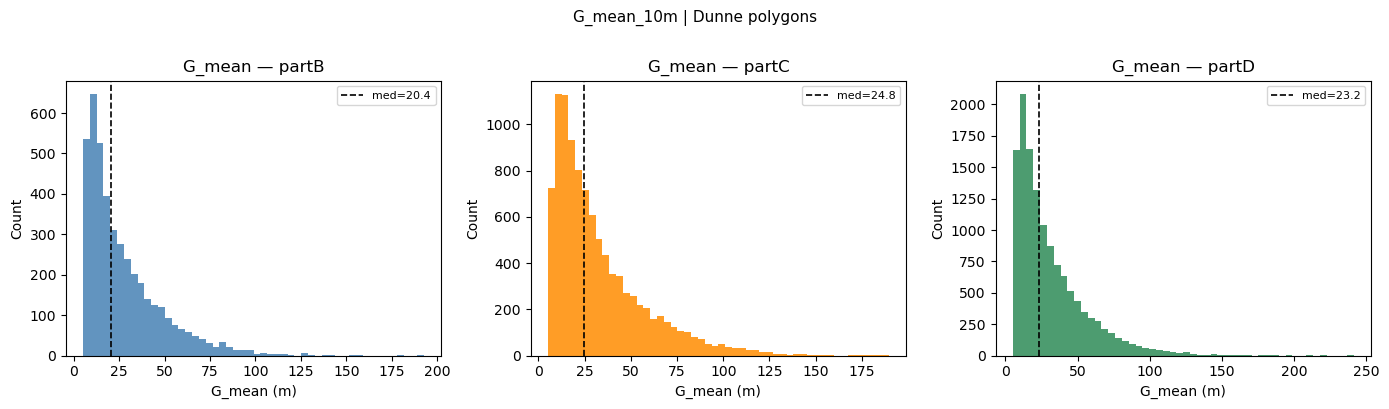

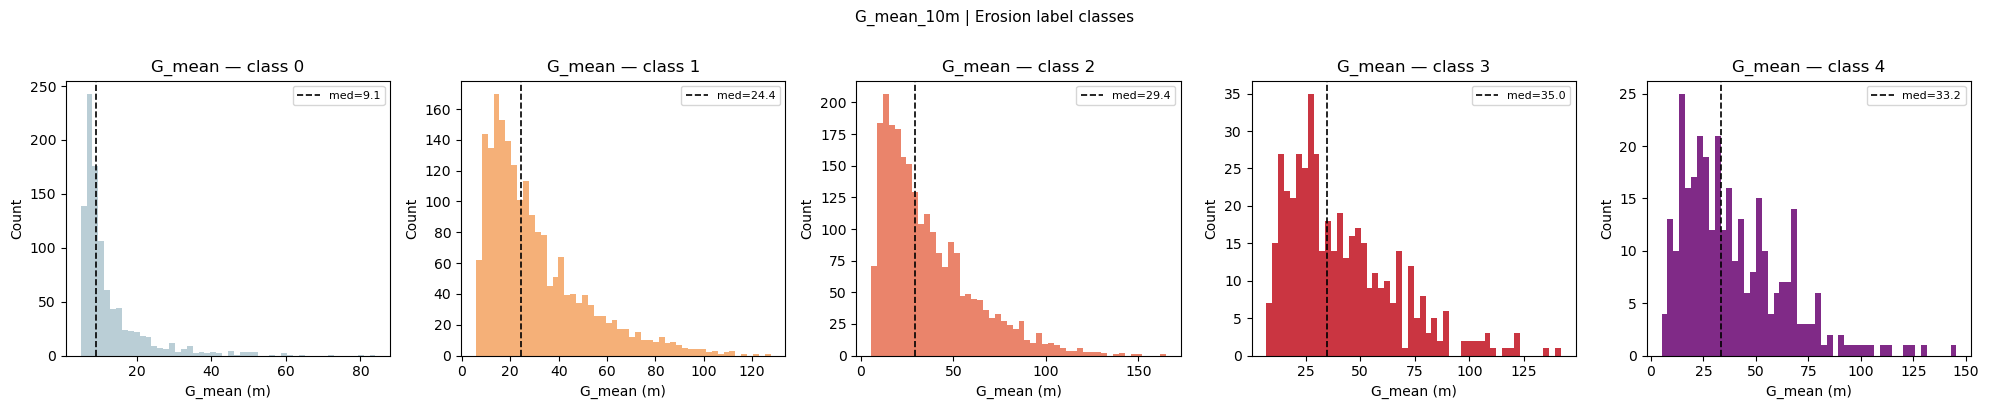

In [ ]:
import numpy as np
import rasterio
import fiona
import matplotlib.pyplot as plt
from rasterio.features import rasterize
from fiona.transform import transform_geom

# ── Load G_mean_10m ──────────────────────────────────────────────────────────
with rasterio.open("/mnt/c/Users/amehedi/Downloads/source_zone_labels/G_mean_10m.tif") as src:
    G   = src.read(1).astype(float)
    tfm = src.transform
    crs = src.crs.to_string()
    nd  = src.nodata
if nd is not None:
    G[np.isclose(G, nd)] = np.nan
H, W = G.shape

# ── Helper: rasterize polygon geometry to same grid ──────────────────────────
def rasterize_geom(shp_path):
    with fiona.open(shp_path) as src:
        src_crs = src.crs_wkt or src.crs.to_wkt()
        shapes = [
            (transform_geom(src_crs, crs, f["geometry"]), 1)
            for f in src if f["geometry"] is not None
        ]
    return rasterize(shapes, out_shape=(H, W), transform=tfm,
                     fill=0, dtype="uint8").astype(bool)

def rasterize_field(shp_path, field):
    with fiona.open(shp_path) as src:
        src_crs = src.crs_wkt or src.crs.to_wkt()
        shapes = [
            (transform_geom(src_crs, crs, f["geometry"]), int(f["properties"][field]))
            for f in src if f["geometry"] is not None
        ]
    return rasterize(shapes, out_shape=(H, W), transform=tfm,
                     fill=-1, dtype="int16")

# ── Build masks ──────────────────────────────────────────────────────────────
dunne_masks = {p: rasterize_geom(f"/mnt/c/Users/amehedi/Downloads/{p}.shp")
               for p in ["partB", "partC", "partD"]}

label_arr   = rasterize_field("/mnt/c/Users/amehedi/Downloads/label_erosion1.shp", "id")
label_masks = {f"class {c}": (label_arr == c) for c in range(5)}

# ── Descriptive stats ────────────────────────────────────────────────────────
def print_stats(name, mask):
    v = G[mask & np.isfinite(G)]
    if len(v) == 0:
        print(f"  {name:12s}  NO DATA"); return
    print(f"  {name:12s}  n={len(v):>6,}  min={np.min(v):8.2f}  "
          f"p25={np.percentile(v,25):8.2f}  med={np.median(v):8.2f}  "
          f"mean={np.mean(v):8.2f}  p75={np.percentile(v,75):8.2f}  max={np.max(v):8.2f}")

print("G_mean_10m — Dunne polygons")
for name, mask in dunne_masks.items():
    print_stats(name, mask)

print("\nG_mean_10m — Erosion label classes")
for name, mask in label_masks.items():
    print_stats(name, mask)

# ── Histograms: Dunne polygons ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, mask), color in zip(axes, dunne_masks.items(),
                                   ["steelblue", "darkorange", "seagreen"]):
    v = G[mask & np.isfinite(G)]
    ax.hist(v, bins=50, color=color, alpha=0.85, edgecolor="none")
    ax.axvline(np.median(v), color="black", lw=1.2, ls="--", label=f"med={np.median(v):.1f}")
    ax.set_title(f"G_mean — {name}")
    ax.set_xlabel("G_mean (m)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)
plt.suptitle("G_mean_10m | Dunne polygons", fontsize=11, y=1.01)
plt.tight_layout(); plt.show()

# ── Histograms: erosion label classes ────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
colors = ["#aec6cf", "#f4a261", "#e76f51", "#c1121f", "#6a0572"]
for ax, (name, mask), color in zip(axes, label_masks.items(), colors):
    v = G[mask & np.isfinite(G)]
    ax.hist(v, bins=50, color=color, alpha=0.85, edgecolor="none")
    ax.axvline(np.median(v), color="black", lw=1.2, ls="--", label=f"med={np.median(v):.1f}")
    ax.set_title(f"G_mean — {name}")
    ax.set_xlabel("G_mean (m)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)
plt.suptitle("G_mean_10m | Erosion label classes", fontsize=11, y=1.01)
plt.tight_layout(); plt.show()


p_union — Dunne polygons
  partB     n= 4,274  min=0.000  p25=0.156  med=0.367  mean=0.421  p75=0.670  max=1.000
  partC     n= 9,963  min=0.000  p25=0.179  med=0.323  mean=0.342  p75=0.472  max=1.000
  partD     n=13,024  min=0.000  p25=0.168  med=0.306  mean=0.326  p75=0.456  max=1.000


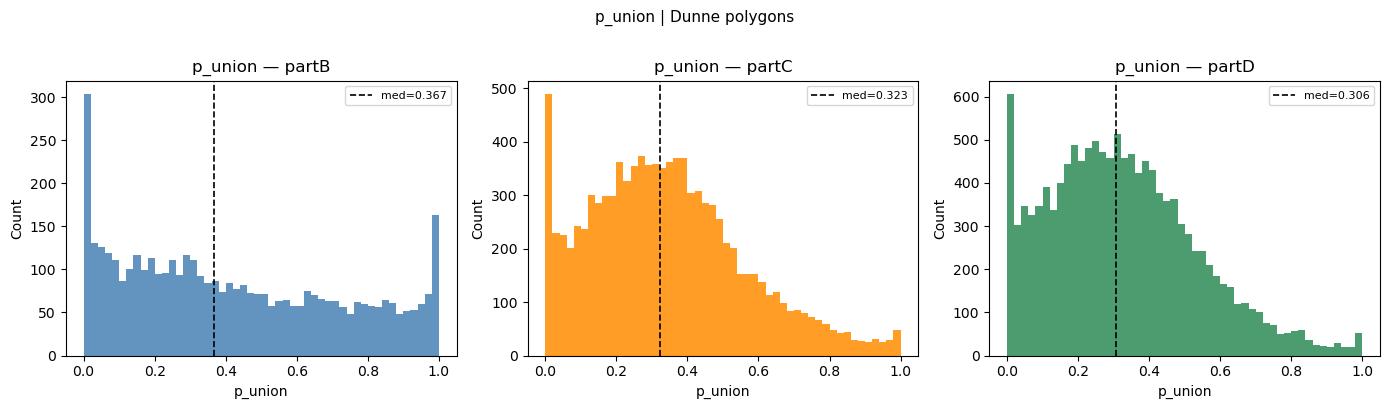


p_union — Erosion label classes
  class 0   n= 1,011  min=0.000  p25=0.004  med=0.048  mean=0.127  p75=0.167  max=1.000
  class 1   n= 1,974  min=0.000  p25=0.174  med=0.310  mean=0.356  p75=0.492  max=1.000
  class 2   n= 2,395  min=0.000  p25=0.211  med=0.357  mean=0.403  p75=0.559  max=1.000
  class 3   n=   462  min=0.013  p25=0.326  med=0.519  mean=0.539  p75=0.759  max=1.000
  class 4   n=   322  min=0.018  p25=0.344  med=0.525  mean=0.543  p75=0.749  max=1.000


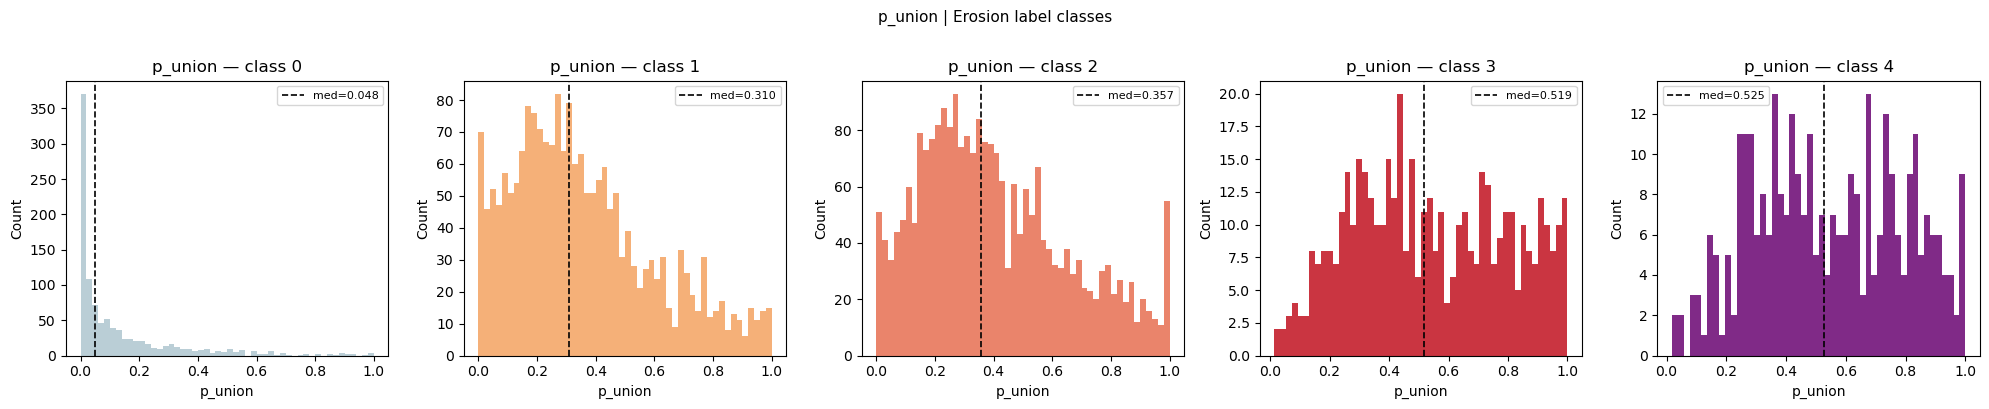


p_inter — Dunne polygons
  partB     n= 4,274  min=0.000  p25=0.004  med=0.066  mean=0.131  p75=0.203  max=0.896
  partC     n= 9,963  min=0.000  p25=0.001  med=0.029  mean=0.072  p75=0.099  max=0.890
  partD     n=13,025  min=0.000  p25=0.000  med=0.026  mean=0.061  p75=0.087  max=0.998


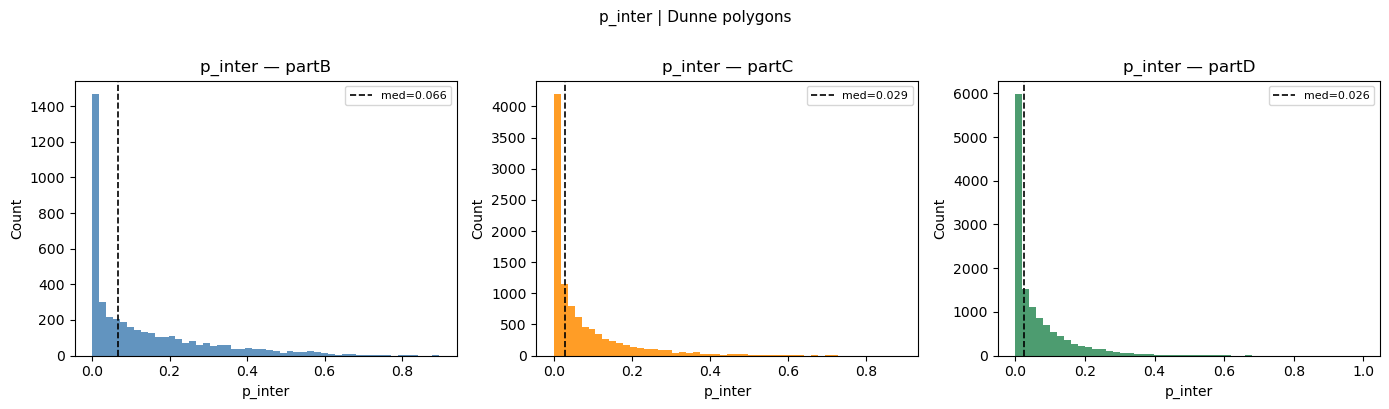


p_inter — Erosion label classes
  class 0   n= 1,011  min=0.000  p25=0.000  med=0.000  mean=0.022  p75=0.010  max=0.633
  class 1   n= 1,974  min=0.000  p25=0.001  med=0.038  mean=0.095  p75=0.136  max=0.754
  class 2   n= 2,395  min=0.000  p25=0.007  med=0.048  mean=0.112  p75=0.166  max=0.914
  class 3   n=   462  min=0.000  p25=0.036  med=0.141  mean=0.186  p75=0.300  max=0.878
  class 4   n=   322  min=0.000  p25=0.061  med=0.143  mean=0.186  p75=0.280  max=0.689


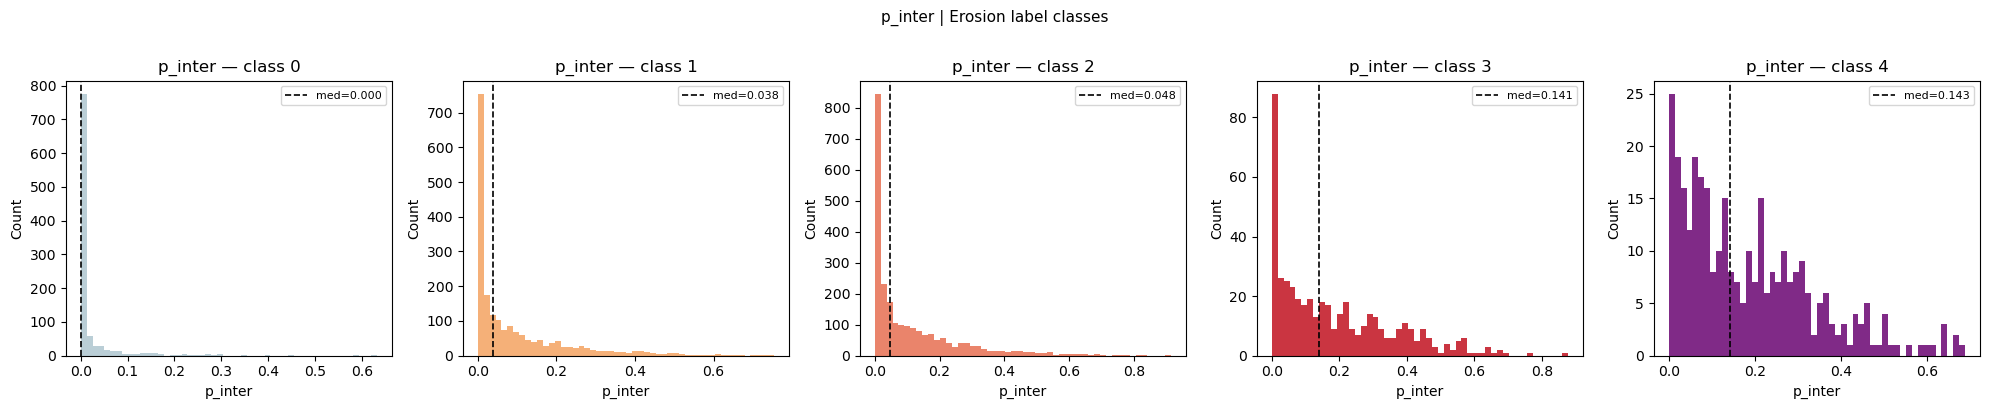

In [10]:
import numpy as np
import rasterio
import fiona
import matplotlib.pyplot as plt
from rasterio.features import rasterize
from fiona.transform import transform_geom

BASE = "/mnt/c/Users/amehedi/Downloads/thomas/aligned/"
SHP  = "/mnt/c/Users/amehedi/Downloads/"

RASTERS = {
    "p_union": BASE + "p_obs_union_aligned.tif",
    "p_inter": BASE + "p_obs_inter_aligned.tif",
}

# ── Load rasters ─────────────────────────────────────────────────────────────
arrays = {}
for name, path in RASTERS.items():
    with rasterio.open(path) as src:
        arr = src.read(1).astype(float)
        tfm = src.transform
        crs = src.crs.to_string()
        nd  = src.nodata
        H, W = arr.shape
    if nd is not None:
        arr[np.isclose(arr, nd)] = np.nan
    arrays[name] = arr

# ── Helpers ───────────────────────────────────────────────────────────────────
def rasterize_geom(shp_path):
    with fiona.open(shp_path) as src:
        src_crs = src.crs_wkt or src.crs.to_wkt()
        shapes = [(transform_geom(src_crs, crs, f["geometry"]), 1)
                  for f in src if f["geometry"] is not None]
    return rasterize(shapes, out_shape=(H, W), transform=tfm,
                     fill=0, dtype="uint8").astype(bool)

def rasterize_field(shp_path, field):
    with fiona.open(shp_path) as src:
        src_crs = src.crs_wkt or src.crs.to_wkt()
        shapes = [(transform_geom(src_crs, crs, f["geometry"]), int(f["properties"][field]))
                  for f in src if f["geometry"] is not None]
    return rasterize(shapes, out_shape=(H, W), transform=tfm,
                     fill=-1, dtype="int16")

# ── Build masks ───────────────────────────────────────────────────────────────
dunne_masks = {p: rasterize_geom(SHP + f"{p}.shp") for p in ["partB", "partC", "partD"]}
label_arr   = rasterize_field(SHP + "label_erosion1.shp", "id")
label_masks = {f"class {c}": (label_arr == c) for c in range(5)}

# ── Stats + plots for each raster ────────────────────────────────────────────
for rname, arr in arrays.items():

    print(f"\n{'='*60}")
    print(f"{rname} — Dunne polygons")
    for name, mask in dunne_masks.items():
        v = arr[mask & np.isfinite(arr)]
        if len(v) == 0: print(f"  {name}: NO DATA"); continue
        print(f"  {name:8s}  n={len(v):>6,}  min={np.min(v):.3f}  "
              f"p25={np.percentile(v,25):.3f}  med={np.median(v):.3f}  "
              f"mean={np.mean(v):.3f}  p75={np.percentile(v,75):.3f}  max={np.max(v):.3f}")

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, (name, mask), color in zip(axes, dunne_masks.items(),
                                       ["steelblue", "darkorange", "seagreen"]):
        v = arr[mask & np.isfinite(arr)]
        ax.hist(v, bins=50, color=color, alpha=0.85, edgecolor="none")
        ax.axvline(np.median(v), color="black", lw=1.2, ls="--", label=f"med={np.median(v):.3f}")
        ax.set_title(f"{rname} — {name}"); ax.set_xlabel(rname); ax.set_ylabel("Count")
        ax.legend(fontsize=8)
    plt.suptitle(f"{rname} | Dunne polygons", fontsize=11, y=1.01)
    plt.tight_layout(); plt.show()

    print(f"\n{rname} — Erosion label classes")
    for name, mask in label_masks.items():
        v = arr[mask & np.isfinite(arr)]
        if len(v) == 0: print(f"  {name}: NO DATA"); continue
        print(f"  {name:8s}  n={len(v):>6,}  min={np.min(v):.3f}  "
              f"p25={np.percentile(v,25):.3f}  med={np.median(v):.3f}  "
              f"mean={np.mean(v):.3f}  p75={np.percentile(v,75):.3f}  max={np.max(v):.3f}")

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    colors = ["#aec6cf", "#f4a261", "#e76f51", "#c1121f", "#6a0572"]
    for ax, (name, mask), color in zip(axes, label_masks.items(), colors):
        v = arr[mask & np.isfinite(arr)]
        ax.hist(v, bins=50, color=color, alpha=0.85, edgecolor="none")
        ax.axvline(np.median(v), color="black", lw=1.2, ls="--", label=f"med={np.median(v):.3f}")
        ax.set_title(f"{rname} — {name}"); ax.set_xlabel(rname); ax.set_ylabel("Count")
        ax.legend(fontsize=8)
    plt.suptitle(f"{rname} | Erosion label classes", fontsize=11, y=1.01)
    plt.tight_layout(); plt.show()


In [4]:
import json
import numpy as np
import rasterio
from pathlib import Path
from scipy.stats import gamma

# ── Paths ─────────────────────────────────────────────────────────────────────
ALIGNED  = Path("/mnt/c/Users/amehedi/Downloads/thomas/aligned")
LABELS   = Path("/mnt/c/Users/amehedi/Downloads/source_zone_labels")
OUT      = ALIGNED   # save notebook outputs alongside aligned layers

P_CEIL   = 0.05
ELEV_MIN = 600.0

# ── Load Gamma fit params ─────────────────────────────────────────────────────
with open(LABELS / "ceff_fit.json") as f:
    fit = json.load(f)
k_fit = fit["k"]
print(f"Gamma fit: k={k_fit:.4f}  scale={fit['scale']:.4f}  n={fit['n_hillslope']:,}")

# ── Load aligned base layers ──────────────────────────────────────────────────
def load(path):
    with rasterio.open(path) as s:
        a = s.read(1).astype("float32")
        if s.nodata is not None:
            a[a == s.nodata] = np.nan
        return a, s.profile.copy()

def save(path, arr, prof, dtype="float32"):
    out = np.where(np.isfinite(arr), arr, -9999.0).astype("float32")
    p = prof.copy()
    p.update(dtype="float32", count=1, nodata=-9999.0, compress="lzw")
    with rasterio.open(path, "w", **p) as dst:
        dst.write(out, 1)
    v = out[out != -9999.0]
    print(f"  {Path(path).name}: valid={len(v):,}  min={v.min():.3f}  max={v.max():.3f}")

g_mean,   prof = load(ALIGNED / "G_mean_aligned.tif")
ch_mask,  _    = load(ALIGNED / "channel_mask_aligned.tif")
elev,     _    = load(ALIGNED / "elevation_aligned.tif")

# ── Domains ───────────────────────────────────────────────────────────────────
hs_domain   = np.isfinite(g_mean) & (ch_mask > 0.5)              # hillslope (all elev)
c_domain    = hs_domain & np.isfinite(elev) & (elev > ELEV_MIN)  # C inversion domain

# ── Gamma inversion helper ────────────────────────────────────────────────────
def invert_C(p_obs, domain):
    """Gamma-invert p_obs → C_eff mean map. Only computed within domain."""
    C = np.full_like(g_mean, np.nan)
    valid = domain & np.isfinite(p_obs) & (p_obs > 0)
    q = gamma.ppf(np.clip(p_obs[valid], 1e-6, 1 - 1e-6), a=k_fit, scale=1)
    ok = q > 0
    C_vals = np.full(valid.sum(), np.nan)
    C_vals[ok] = k_fit * (g_mean[valid][ok] / q[ok])
    C[valid] = C_vals
    return C

# ── Process both methods ──────────────────────────────────────────────────────
for method, fname in [("union", "p_obs_union_aligned.tif"),
                      ("inter", "p_obs_inter_aligned.tif")]:
    print(f"\n── {method.upper()} ──")
    p_obs, _ = load(ALIGNED / fname)

    # 1. Binary zero-mask: 1 where p_obs=0, 0 where p_obs>0, NaN outside domain
    zero_mask = np.full_like(p_obs, np.nan)
    zero_mask[hs_domain & np.isfinite(p_obs) & (p_obs == 0)] = 1.0
    zero_mask[hs_domain & np.isfinite(p_obs) & (p_obs  > 0)] = 0.0
    save(OUT / f"p_obs_{method}_zero_mask.tif", zero_mask, prof)

    # 2. Updated p_obs: replace 0 → P_CEIL (only for observed 0s, not NaN)
    p_updated = p_obs.copy()
    p_updated[np.isfinite(p_obs) & (p_obs == 0)] = P_CEIL
    save(OUT / f"p_obs_{method}_updated.tif", p_updated, prof)

    # 3. C from updated p_obs (elev > 600m domain)
    C_upd = invert_C(p_updated, c_domain)
    save(OUT / f"C_p_obs_{method}_updated.tif",     C_upd, prof)
    save(OUT / f"C_p_obs_{method}_updated_log.tif", np.log(np.clip(C_upd, 1e-6, None)), prof)

    print(f"  zero-mask: {int(np.nansum(zero_mask == 1)):,} pixels with p=0 → will use C_p005")

print("\nDone.")


Gamma fit: k=2.1291  scale=13.6977  n=210,577

── UNION ──
  p_obs_union_zero_mask.tif: valid=354,237  min=0.000  max=1.000
  p_obs_union_updated.tif: valid=354,237  min=0.000  max=1.000
  C_p_obs_union_updated.tif: valid=159,838  min=0.694  max=12748.886
  C_p_obs_union_updated_log.tif: valid=159,838  min=-0.365  max=9.453
  zero-mask: 12,451 pixels with p=0 → will use C_p005

── INTER ──
  p_obs_inter_zero_mask.tif: valid=354,237  min=0.000  max=1.000
  p_obs_inter_updated.tif: valid=354,237  min=0.000  max=1.000
  C_p_obs_inter_updated.tif: valid=159,838  min=0.699  max=35480.570
  C_p_obs_inter_updated_log.tif: valid=159,838  min=-0.359  max=10.477
  zero-mask: 137,220 pixels with p=0 → will use C_p005

Done.


In [1]:
import numpy as np
import rasterio
from pathlib import Path

PRE  = Path("/mnt/c/Users/amehedi/Downloads/dodson_2009.tif")
POST = Path("/mnt/c/Users/amehedi/Downloads/dodson_2018_c.tif")
OUT  = Path("/mnt/c/Users/amehedi/Downloads/dodson_ddem.tif")

with rasterio.open(PRE) as src_pre, rasterio.open(POST) as src_post:
    pre  = src_pre.read(1).astype("float32")
    post = src_post.read(1).astype("float32")
    prof = src_pre.profile.copy()

    # mask nodata
    nd = src_pre.nodata
    pre [pre  == nd] = np.nan
    post[post == nd] = np.nan

ddem = post - pre   # positive = deposition, negative = erosion

out = np.where(np.isfinite(ddem), ddem, nd).astype("float32")
prof.update(nodata=nd, compress="lzw")

with rasterio.open(OUT, "w", **prof) as dst:
    dst.write(out, 1)

v = ddem[np.isfinite(ddem)]
print(f"dDEM saved: {OUT.name}")
print(f"  valid px : {len(v):,}")
print(f"  min={v.min():.2f}  max={v.max():.2f}  mean={v.mean():.2f}  std={v.std():.2f}")


dDEM saved: dodson_ddem.tif
  valid px : 20,689,589
  min=-78.73  max=135.88  mean=-0.09  std=1.72


In [3]:
import whitebox
import numpy as np
import rasterio
import pandas as pd
from pathlib import Path

wbt = whitebox.WhiteboxTools()
wbt.verbose = False

BASE = Path("/mnt/c/Users/amehedi/Downloads")
OUT  = BASE / "eagle_creek_derivs"
OUT.mkdir(exist_ok=True)

PRE  = BASE / "dodson_2009.tif"
POST = BASE / "dodson_2018_c.tif"
DDEM = BASE / "dodson_ddem.tif"

# ── G computation ─────────────────────────────────────────────────────────────
def compute_G(dem, tag):
    filled = str(OUT / f"filled_{tag}.tif")
    sca    = str(OUT / f"sca_{tag}.tif")
    slp    = str(OUT / f"slope_{tag}.tif")
    G_out  = OUT / f"G_{tag}.tif"

    wbt.breach_depressions_least_cost(str(dem), filled, dist=5, fill=True)
    wbt.d_inf_flow_accumulation(filled, sca)
    wbt.slope(filled, slp, units="degrees")

    with rasterio.open(sca) as s1, rasterio.open(slp) as s2:
        SCA  = s1.read(1).astype("float32");  SCA[SCA  == s1.nodata] = np.nan
        Sdeg = s2.read(1).astype("float32"); Sdeg[Sdeg == s2.nodata] = np.nan
        prof = s1.profile.copy()

    G = SCA * np.tan(np.radians(Sdeg))
    out = np.where(np.isfinite(G), G, -9999.0).astype("float32")
    prof.update(nodata=-9999.0, compress="lzw")
    with rasterio.open(G_out, "w", **prof) as dst:
        dst.write(out, 1)
    print(f"G_{tag}: mean={np.nanmean(G):.2f}  max={np.nanmax(G):.2f}")
    return G

G_pre  = compute_G(PRE,  "pre")
G_post = compute_G(POST, "post")

# ── ΔG ────────────────────────────────────────────────────────────────────────
with rasterio.open(OUT / "G_pre.tif") as s:
    gp   = s.read(1).astype("float32"); gp[gp == s.nodata] = np.nan
    prof = s.profile.copy()
with rasterio.open(OUT / "G_post.tif") as s:
    gq = s.read(1).astype("float32"); gq[gq == s.nodata] = np.nan

dG  = gq - gp
out = np.where(np.isfinite(dG), dG, -9999.0).astype("float32")
prof.update(nodata=-9999.0, compress="lzw")
with rasterio.open(OUT / "dG.tif", "w", **prof) as dst:
    dst.write(out, 1)
print(f"dG: mean={np.nanmean(dG):.2f}  min={np.nanmin(dG):.2f}  max={np.nanmax(dG):.2f}")

# ── Curvature ─────────────────────────────────────────────────────────────────
for dem, tag in [(PRE, "pre"), (POST, "post")]:
    wbt.profile_curvature(str(dem), str(OUT / f"curvature_{tag}.tif"))
    print(f"curvature_{tag} done")

print("\nAll derivatives saved to:", OUT)


G_pre: mean=442.46  max=15225833.00
G_post: mean=392.95  max=24790158.00
dG: mean=5.89  min=-11842646.00  max=24790146.00
curvature_pre done
curvature_post done

All derivatives saved to: /mnt/c/Users/amehedi/Downloads/eagle_creek_derivs


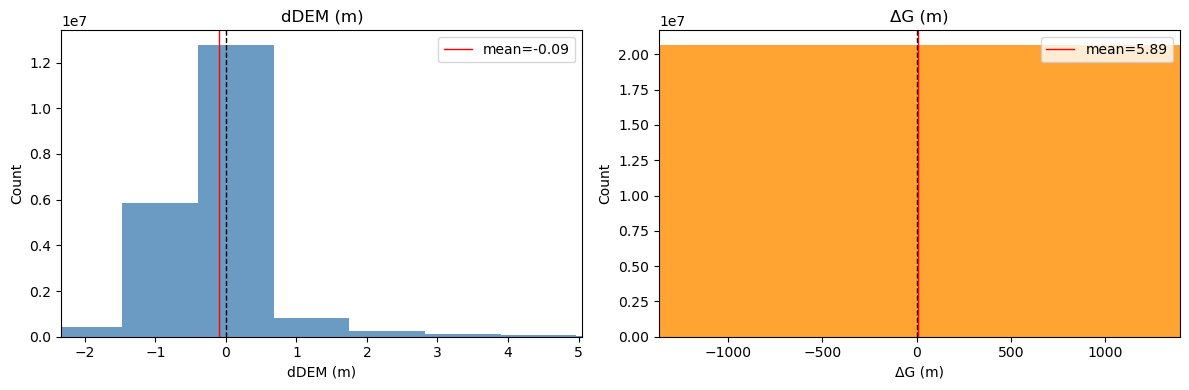

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, arr, name, color in [
    (axes[0], ddem, "dDEM (m)",  "steelblue"),
    (axes[1], dG,   "ΔG (m)",    "darkorange"),
]:
    v = arr[np.isfinite(arr)]
    ax.hist(v, bins=200, color=color, alpha=0.8, edgecolor="none")
    ax.axvline(0, color="black", lw=1, ls="--")
    ax.axvline(v.mean(), color="red", lw=1, ls="-", label=f"mean={v.mean():.2f}")
    ax.set_title(name)
    ax.set_xlabel(name)
    ax.set_xlim(np.percentile(v, 1), np.percentile(v, 99))
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.show()

In [6]:
def desc_stats(arr, name):
    v = arr[np.isfinite(arr)]
    return {"layer":  name,
            "n":      f"{len(v):,}",
            "min":    round(v.min(), 3),
            "max":    round(v.max(), 3),
            "mean":   round(v.mean(), 3),
            "median": round(np.median(v), 3),
            "std":    round(v.std(), 3),
            "p5":     round(np.percentile(v,  5), 3),
            "p95":    round(np.percentile(v, 95), 3)}

df = pd.DataFrame([desc_stats(ddem, "dDEM (m)"),
                   desc_stats(dG,   "ΔG (m)")]).set_index("layer")
display(df)


,n,min,max,mean,median,std,p5,p95
layer,,,,,,,,
dDEM (m),"20,689,589",-7.872700e+01,1.358810e+02,-0.094,-0.178,1.722000,-1.179000,1.029000
ΔG (m),"20,689,589",-1.184265e+07,2.479015e+07,5.891,0.020,24427.681641,-140.085007,130.682007
